Calculate surface energy and water budgets from an AM3 run

Creates plots in `/scratch/$PROJECT/$USER`
```
runname_energybal.png
runmame_waterbal.png
```

In [1]:
import xarray as xr
import iris
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import warnings
import datetime
import os
from pathlib import Path
import yaml
%matplotlib inline

In [2]:
from dask.distributed import Client
client = Client(threads_per_worker = 1)

In [3]:
# archive = Path('/scratch/tm70/mrd599/cylc-run/am3-dev-n96e/run1/share/data/History_Data')
# prefix = 'deva'
# suite = 'access-am3-dev-n96e'
suite = 'access-am3-CABLE-science-update'
prefix = 'am3a'
archive = Path(f'/scratch/tm70/lw5085/cylc-run/{suite}/share/data/History_Data')
# Set to None for all available years
firstyear = None
lastyear = None

In [4]:
def savefig(name):
    # Saves plots to /scratch/$PROJECT/$USER
    # Adds a metadata string to aid in identifying plots
    basepath = Path('/scratch') / os.environ['PROJECT'] / os.environ['USER']
    path = basepath / name
    date = datetime.datetime.today().strftime("%Y-%m-%d %H:%M")
    plt.savefig(path, dpi=150, bbox_inches='tight',
        metadata={"History": (f"{name} created by am3_energy_water_balance.ipynb at "
                              f"{date}")})

def annual_mean(ds):
    """ Properly month length weighted annual mean of a DataArray"""
    if not ds.time.dt.month[0] == 1:
        raise ValueError("Data does not start with January")
    if not ds.time.dt.month[1] == 2:
        raise ValueError("Non-monthly data")
    # Process only complete years
    nmon = 12*(len(ds.time)//12)
    month_length = ds.time.dt.days_in_month[:nmon]
    weights = month_length.groupby('time.year') / month_length.groupby('time.year').sum()
    ann_mean = (ds[:nmon]*weights).groupby('time.year').sum(dim='time',min_count=1)
    return ann_mean

In [5]:
# Restricting it to just the required fields is faster
reqd = ['fld_s05i216', # precip
        'fld_s03i223', # evap
        'fld_s08i234', 'fld_s08i235',  # runoff
        'fld_s01i201', # rss
        'fld_s02i201', # rls
        'fld_s03i217', # hfss
        'fld_s03i234', # hfls
        'fld_s03i258',  # snm
        'fld_s03i236',  # tas
        'fld_s08i023',  # snow mass,
        # 'fld_s03i314',  # netrad on tiles
        # 'fld_s03i317',  # tile fractions
        'time_bnds', 'lon_bnds', 'lat_bnds'
]

def _preprocess(d):
    return xr.Dataset({v:d[v] for v in reqd})

file_list = []
for file in sorted(archive.glob(f'netCDF/{prefix}.pm*.nc')):
    # Name of form prefix.pmYYYYmon.nc
    year = int(file.name[-10:-6])
    if not ((firstyear and year < firstyear) or (lastyear and year > lastyear)):
        file_list.append(file)
d = xr.open_mfdataset(file_list, combine='by_coords',
                     preprocess=_preprocess, parallel=True)


/jobfs/163843805.gadi-pbs/ipykernel_2120452/3555595061.py:26: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  d = xr.open_mfdataset(file_list, combine='by_coords',


In [6]:
if firstyear == 0:
    initial_restart = archive / f'{prefix}.da{firstyear:04d}0101_00'
else:
    initial_restart = archive.parent / f'{prefix}.astart'

# Want the restart file that matches the final monthly mean
if lastyear:
    yearno = lastyear
else:
    yearno = d['fld_s03i236'].time.data[-1].year
final_restart = archive / f'{prefix}.da{(yearno+1):04d}0101_00'

print('Restarts', initial_restart, final_restart)

# Get initial and final water content from the restart files

# The non-instantaneous fields in restarts can loading problems so
# skip them with a callback. This is also faster
def instantaneous_callback(cube, field, filename):
    # Non-instantaneous fields have a cell_methods attribute which describes the
    # time processing.
    if cube.cell_methods:
        raise iris.exceptions.IgnoreCubeException

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="The stash code")
    sftlf = iris.load_cube(initial_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i505'))
    landCoverFrac = iris.load_cube(initial_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i216'))
    mrsol0 = iris.load_cube(initial_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i009'))
    canopy0 = iris.load_cube(initial_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i022'))
    snow0 = iris.load_cube(initial_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i023'))
    mrsol1 = iris.load_cube(final_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i009'))
    snow1 = iris.load_cube(final_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i023'))
    canopy1 = iris.load_cube(final_restart, callback=instantaneous_callback,
                    constraint=iris.AttributeConstraint(STASH='m01s00i022'))
mtot0 = xr.DataArray.from_iris(mrsol0).sum('depth').rename({'latitude':'lat', 'longitude':'lon'})
mtot1 = xr.DataArray.from_iris(mrsol1).sum('depth').rename({'latitude':'lat', 'longitude':'lon'})
snow0 = xr.DataArray.from_iris(snow0).rename({'latitude':'lat', 'longitude':'lon'})
snow1 = xr.DataArray.from_iris(snow1).rename({'latitude':'lat', 'longitude':'lon'})
canopy0 = xr.DataArray.from_iris(canopy0).rename({'latitude':'lat', 'longitude':'lon'})
canopy1 = xr.DataArray.from_iris(canopy1).rename({'latitude':'lat', 'longitude':'lon'})
sftlf = xr.DataArray.from_iris(sftlf).rename({'latitude':'lat', 'longitude':'lon'})
landCoverFrac = xr.DataArray.from_iris(landCoverFrac).rename({'pseudo_level':'type', 'latitude':'lat', 'longitude':'lon'})

# Need to load to avoid getting a size zero array?
tmp = d.time_bnds.load()
t1 = tmp.data[0,0]  # Start time
t2 = tmp.data[-1,1] # End time
ndays = (t2 - t1).days
# Change to kg/m^2/s to match net_water
delta_water = (mtot1 + snow1 - mtot0 - snow0 + canopy1 - canopy0)/(86400*ndays)

area = xr.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/piControl/r1i1p1f1/fx/areacella/gn/latest/areacella_fx_ACCESS-CM2_piControl_r1i1p1f1_gn.nc').areacella

land = xr.where(sftlf >= 1., 0, np.nan)

lakes = xr.where(landCoverFrac[15] > 0, np.nan, 0)
ice = xr.where(landCoverFrac[16] > 0, np.nan, 0)

mask = land + lakes + ice

Restarts /scratch/tm70/lw5085/cylc-run/access-am3-CABLE-science-update/share/data/am3a.astart /scratch/tm70/lw5085/cylc-run/access-am3-CABLE-science-update/share/data/History_Data/am3a.da19830101_00


In [7]:
pr = d['fld_s05i216']
evspsbl  = d['fld_s03i223']
runoff = d['fld_s08i234'] + d['fld_s08i235']

net_water = (pr - evspsbl - runoff)
net_water_mean = annual_mean(net_water).mean('year').load()

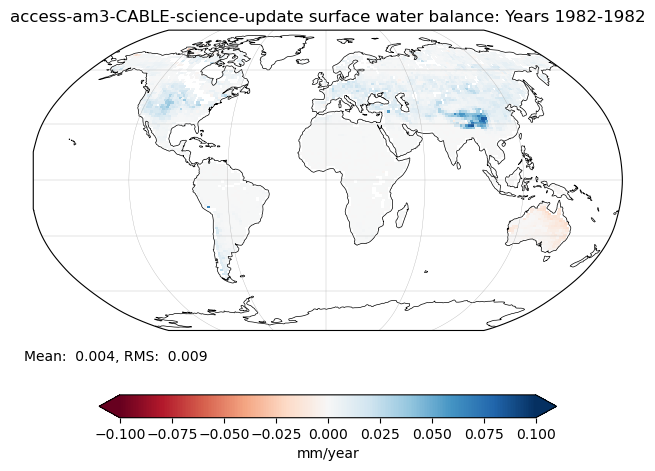

In [12]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection=ccrs.Robinson())
ax.coastlines(resolution='110m',linewidth=0.5)
ax.gridlines(draw_labels=False,linewidth=0.25)
# Convert to mm/year
diff = 365*86400*(net_water_mean - delta_water) + mask
p = diff.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap='RdBu', vmax=0.1)
plt.colorbar(p, shrink=0.75, orientation='horizontal', extend='both', label='mm/year')
y1 = net_water.time.data[0].year
y2 = net_water.time.data[-1].year
ax.set_title(f'{suite} surface water balance: Years {y1}-{y2}')
mean = (diff*area).sum() / (area+mask).sum()
rms = ((diff*diff*area).sum() / (area+mask).sum())**0.5
mean = float(mean.data)
rms = float(rms.data)
fig.text(0.025, 0.25, f"Mean: {mean:6.3f}, RMS: {rms:6.3f}")
plt.tight_layout()
savefig(f'{suite}_waterbal1_{y1}_{y2}.png')


In [9]:
rls = d['fld_s02i201']
rss = d['fld_s01i201']
hfss = d['fld_s03i217']
hfls = d['fld_s03i234']
snm = d['fld_s03i258']

# Use monthly tile fractions to allow for changes in vegetation
# Find the tile dimension name of netrad
# This may differ depending on which output fields were saved
# v = d['fld_s03i314']
# for x in v.coords:
#     # Use shape rather than len to avoid problems with zero length coordinates
#     if x.startswith('pseudo_level') and v[x].shape == (17,):
#         tile_coord = x
# netrad = (d['fld_s03i314']*d['fld_s03i317']).sum(tile_coord)

net_energy = (rss + rls - hfss - hfls - snm)
net_energy_mean = annual_mean(net_energy).mean('year').load()

# net_energy2 = (netrad - hfss - hfls - snm)
# net_energy2_mean = annual_mean(net_energy2).mean('year').load()

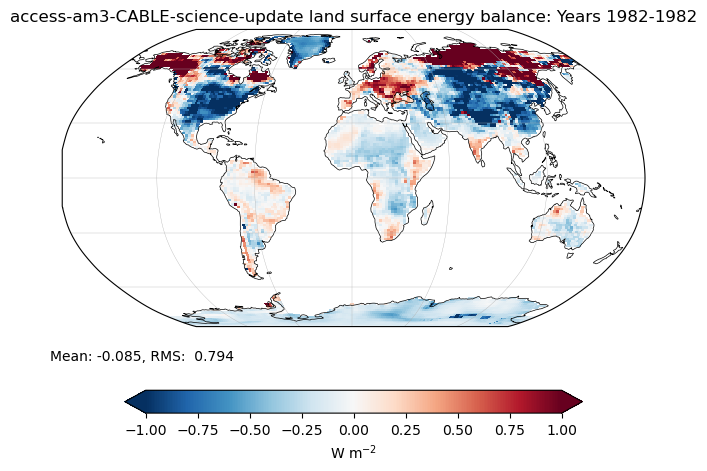

In [10]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection=ccrs.Robinson())
ax.coastlines(resolution='110m',linewidth=0.5)
ax.gridlines(draw_labels=False,linewidth=0.25)
diff = net_energy_mean + land
p = diff.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, vmax=1)
plt.colorbar(p, shrink=0.75, orientation='horizontal', extend='both', label='W m$^{-2}$')
y1 = net_energy.time.data[0].year
y2 = net_energy.time.data[-1].year
ax.set_title(f'{suite} land surface energy balance: Years {y1}-{y2}')
mean = (diff*area).sum() / (area+land).sum()
rms = ((diff*diff*area).sum() / (area+land).sum())**0.5
mean = float(mean.data)
rms = float(rms.data)
fig.text(0.025, 0.25, f"Mean: {mean:6.3f}, RMS: {rms:6.3f}")
plt.tight_layout()
savefig(f'{suite}_energybal_{y1}-{y2}.png')


In [11]:
# fig = plt.figure()
# ax = fig.add_subplot(1,1,1,projection=ccrs.Robinson())
# ax.coastlines(resolution='110m',linewidth=0.5)
# ax.gridlines(draw_labels=False,linewidth=0.25)
# diff = net_energy2_mean + land
# p = diff.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, vmax=3)
# plt.colorbar(p, shrink=0.75, orientation='horizontal', extend='both', label='W m$^{-2}$')
# y1 = net_energy.time.data[0].year
# y2 = net_energy.time.data[-1].year
# ax.set_title(f'{archive.name} surface energy balance using netrad: Years {y1}-{y2}')
# mean = (diff*area).sum() / (area+land).sum()
# rms = ((diff*diff*area).sum() / (area+land).sum())**0.5
# mean = float(mean.data)
# rms = float(rms.data)
# fig.text(0.025, 0.25, f"Mean: {mean:6.3f}, RMS: {rms:6.3f}")
# plt.tight_layout()
# savefig(f'{archive.name}_energybal_netrad_{y1}-{y2}.png')